In [2]:
from __future__ import annotations

import json
from glob import glob
from contextlib import suppress

import matplotlib.pyplot as plt
import pandas as pd

/tmp/ipykernel_1347806/63922292.py:8: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
DATA_DIR = "results/2024-02-19-scaling"

In [4]:
data = []
for file in glob(DATA_DIR + "/**/*run1.json", recursive=True):
    results: dict = json.load(open(file))
    results.pop("results")
    # XXX(JW): Remove later when I update the benchmarking script.
    pieces = file.split("/")[-1].split("-")[0].split("+")
    results["num_gpus"] = int(pieces[-1][4:])
    results["power_limit"] = int(pieces[-2][2:])
    data.append(results)

df = pd.DataFrame(data)

In [5]:
df

,model,backend,request_rate,num_requests,num_failures,system_prompt,total_benchmark_runtime,requests_per_second,total_prompt_tokens,total_completion_tokens,...,server_side_total_energy,server_side_energy_per_request,server_side_energy_per_output_token,server_side_average_power,client_side_total_energy,client_side_energy_per_request,client_side_energy_per_output_token,client_side_average_power,num_gpus,power_limit
0,meta-llama/Llama-2-13b-chat-hf,vllm,5.000,500,0,You are an artifical intellicence assistant th...,234.689681,2.130473,68836,230694,...,134795.488664,269.590977,0.584304,574.356266,156025.350,312.050700,0.676330,664.815553,4,300
1,meta-llama/Llama-2-13b-chat-hf,vllm,4.500,500,0,You are an artifical intellicence assistant th...,239.149729,2.090740,68836,228701,...,139346.937793,278.693876,0.609297,582.676546,157089.795,314.179590,0.686878,656.867963,4,300
2,meta-llama/Llama-2-13b-chat-hf,vllm,4.000,500,0,You are an artifical intellicence assistant th...,241.135759,2.073521,68836,231958,...,140733.178234,281.466356,0.606718,583.626332,160293.147,320.586294,0.691044,664.742334,4,300
3,meta-llama/Llama-2-13b-chat-hf,vllm,3.500,500,0,You are an artifical intellicence assistant th...,237.122060,2.108619,68836,227020,...,140942.964011,281.885928,0.620839,594.389927,158250.093,316.500186,0.697076,667.378197,4,300
4,meta-llama/Llama-2-13b-chat-hf,vllm,3.000,500,0,You are an artifical intellicence assistant th...,257.947284,1.938381,68836,232899,...,153364.358747,306.728717,0.658502,594.556982,169908.027,339.816054,0.729535,658.692832,4,300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,meta-llama/Llama-2-13b-chat-hf,vllm,0.625,500,0,You are an artifical intellicence assistant th...,1833.743626,0.272666,68836,230334,...,213074.285000,426.148570,0.925067,116.196333,217208.834,434.417668,0.943017,118.451037,1,100
284,meta-llama/Llama-2-13b-chat-hf,vllm,0.500,500,0,You are an artifical intellicence assistant th...,1817.494731,0.275104,68836,230344,...,211411.673000,422.823346,0.917808,116.320377,215358.581,430.717162,0.934943,118.491997,1,100
285,meta-llama/Llama-2-13b-chat-hf,vllm,0.375,500,0,You are an artifical intellicence assistant th...,1859.687073,0.268862,68836,233467,...,212406.656000,424.813312,0.909793,114.216343,220803.900,441.607800,0.945761,118.731750,1,100
286,meta-llama/Llama-2-13b-chat-hf,vllm,0.250,500,0,You are an artifical intellicence assistant th...,2158.403780,0.231653,68836,234311,...,261828.623000,523.657246,1.117441,121.306600,268318.294,536.636588,1.145137,124.313299,1,100


In [6]:
df.columns

Index(['model', 'backend', 'request_rate', 'num_requests', 'num_failures',
       'system_prompt', 'total_benchmark_runtime', 'requests_per_second',
       'total_prompt_tokens', 'total_completion_tokens', 'latency_per_request',
       'latency_per_output_token', 'server_side_total_energy',
       'server_side_energy_per_request', 'server_side_energy_per_output_token',
       'server_side_average_power', 'client_side_total_energy',
       'client_side_energy_per_request', 'client_side_energy_per_output_token',
       'client_side_average_power', 'num_gpus', 'power_limit'],
      dtype='object')

In [7]:
df.loc[(df.power_limit == 300) & (0.8<= df.requests_per_second) & (df.requests_per_second <= 1.2)][["request_rate", "requests_per_second", "client_side_energy_per_request", "latency_per_output_token", "num_gpus"]]#.plot(x="num_gpus", y="client_side_energy_per_request")

,request_rate,requests_per_second,client_side_energy_per_request,latency_per_output_token,num_gpus
8,1.00,0.883344,632.740670,0.076529,4
17,1.25,1.098391,418.236296,0.068717,2
18,1.00,0.917522,483.495142,0.062787,2


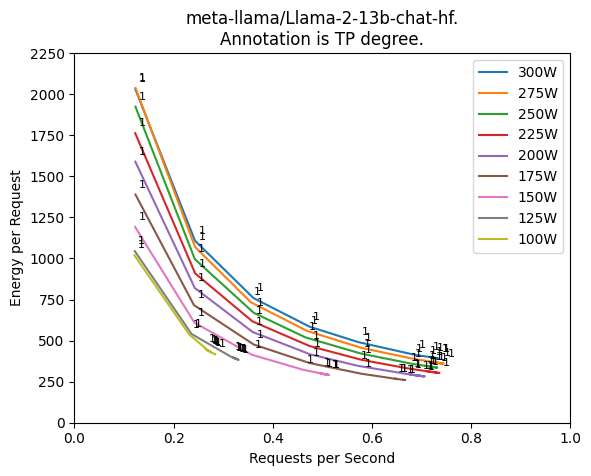

In [8]:
unique_power_limits = df['power_limit'].unique()

fig, ax = plt.subplots()

for power_limit in unique_power_limits:
    filtered_df = df.loc[(df['power_limit'] == power_limit) & (df['num_gpus'] == 1)]
    
    filtered_df = filtered_df.sort_values(by='request_rate')
    
    ax.plot(filtered_df['requests_per_second'], filtered_df['client_side_energy_per_request'], label=f'{power_limit}W')#, s=5)
    
    for _, row in filtered_df.iterrows():
        ax.annotate(row['num_gpus'], (row['requests_per_second'], row['client_side_energy_per_request']), textcoords="offset points", xytext=(5,5), ha='center', fontsize=8)

ax.set_xlim(0, 1.0)
ax.set_ylim(0, 2250)
ax.set_xlabel('Requests per Second')
ax.set_ylabel('Energy per Request')
ax.set_title(f"{df.iloc[0].model}.\nAnnotation is TP degree.")
ax.legend()

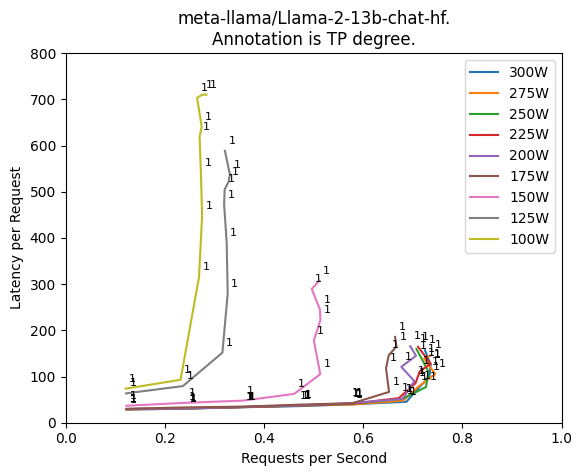

In [9]:
unique_power_limits = df['power_limit'].unique()

fig, ax = plt.subplots()

for power_limit in unique_power_limits:
    filtered_df = df.loc[(df['power_limit'] == power_limit) & (df['num_gpus'] == 1)]
    
    filtered_df = filtered_df.sort_values(by='request_rate')
    
    ax.plot(filtered_df['requests_per_second'], filtered_df['latency_per_request'], label=f'{power_limit}W')#, s=5)
    
    for _, row in filtered_df.iterrows():
        ax.annotate(row['num_gpus'], (row['requests_per_second'], row['latency_per_request']), textcoords="offset points", xytext=(5,5), ha='center', fontsize=8)

ax.set_xlim(0, 1.0)
ax.set_ylim(0, 800)
ax.set_xlabel('Requests per Second')
ax.set_ylabel('Latency per Request')
ax.set_title(f"{df.iloc[0].model}.\nAnnotation is TP degree.")
ax.legend()